# Task
Analyze the energy consumption of various appliances by detecting all unique appliance names from the provided X_train_<appliance>.csv and y_train_<appliance>.csv files, then for each appliance, train a Linear Regression model, evaluate its performance using MAE and RMSE, visualize actual vs. predicted consumption, save the trained model, and finally, present a performance comparison table with observations.

## Discover Appliances and Prepare Data

### Subtask:
Automatically detect all unique appliance names from the available X_train_<appliance>.csv and y_train_<appliance>.csv files. Load the training and testing datasets (X_train, y_train, X_test, y_test) for each identified appliance.


**Reasoning**:
The subtask requires identifying unique appliance names from the provided file patterns and then loading the corresponding training and testing datasets for each appliance. The first step is to import the necessary libraries, `pandas` for data manipulation and `glob` for file pattern matching.



In [1]:
import pandas as pd
import glob

# Initialize an empty list to store unique appliance names
appliance_names = []

# Use glob to find all files matching the pattern 'X_train_*.csv'
x_train_files = glob.glob('X_train_*.csv')

# Iterate through the found file paths to extract appliance names
for file_path in x_train_files:
    # Extract the base filename (e.g., 'X_train_Fridge.csv')
    filename = file_path.split('/')[-1]
    # Extract the appliance name by removing 'X_train_' prefix and '.csv' suffix
    appliance_name = filename.replace('X_train_', '').replace('.csv', '')
    if appliance_name not in appliance_names:
        appliance_names.append(appliance_name)

print(f"Discovered appliances: {appliance_names}")

# Initialize an empty dictionary to store the loaded datasets
data_by_appliance = {}

# Iterate through each unique appliance name to load the datasets
for appliance in appliance_names:
    try:
        # Construct file paths
        x_train_path = f"X_train_{appliance}.csv"
        y_train_path = f"y_train_{appliance}.csv"
        x_test_path = f"X_test_{appliance}.csv"
        y_test_path = f"y_test_{appliance}.csv"

        # Load datasets
        X_train_df = pd.read_csv(x_train_path)
        y_train_df = pd.read_csv(y_train_path)
        X_test_df = pd.read_csv(x_test_path)
        y_test_df = pd.read_csv(y_test_path)

        # Store dataframes in the dictionary
        data_by_appliance[appliance] = {
            'X_train': X_train_df,
            'y_train': y_train_df,
            'X_test': X_test_df,
            'y_test': y_test_df
        }
        print(f"Successfully loaded data for {appliance}")
    except FileNotFoundError as e:
        print(f"Error loading data for {appliance}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred for {appliance}: {e}")

print("Data loading complete. The 'data_by_appliance' dictionary contains all loaded datasets.")

Discovered appliances: ['Oven', 'Air_Conditioning', 'Dishwasher', 'Microwave', 'Lights', 'Heater', 'TV', 'Washing_Machine', 'Computer', 'Fridge']
Successfully loaded data for Oven
Successfully loaded data for Air_Conditioning
Successfully loaded data for Dishwasher
Successfully loaded data for Microwave
Successfully loaded data for Lights
Successfully loaded data for Heater
Successfully loaded data for TV
Successfully loaded data for Washing_Machine
Successfully loaded data for Computer
Successfully loaded data for Fridge
Data loading complete. The 'data_by_appliance' dictionary contains all loaded datasets.


## Train and Evaluate Linear Regression Models

### Subtask:
For each appliance, train a Linear Regression model using the loaded training data. Generate energy consumption predictions on the test set. Calculate and store standard regression metrics: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).


**Reasoning**:
The next step is to implement the training and evaluation of Linear Regression models for each appliance, as outlined in the subtask. This involves importing necessary libraries, iterating through appliances, training models, generating predictions, and calculating evaluation metrics (MAE and RMSE), storing all results in a dictionary.



In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize a dictionary to store model results
model_results = {}

# Iterate through each appliance to train and evaluate models
for appliance in appliance_names:
    print(f"\nProcessing appliance: {appliance}")

    # Retrieve data for the current appliance
    X_train = data_by_appliance[appliance]['X_train']
    y_train = data_by_appliance[appliance]['y_train']
    X_test = data_by_appliance[appliance]['X_test']
    y_test = data_by_appliance[appliance]['y_test']

    # Initialize and train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    print(f"Model trained for {appliance}")

    # Generate predictions on the test set
    predictions = model.predict(X_test)

    # Ensure y_test is a 1D array for metric calculation
    y_test_flat = y_test.values.flatten()
    predictions_flat = predictions.flatten()

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test_flat, predictions_flat)
    rmse = np.sqrt(mean_squared_error(y_test_flat, predictions_flat))

    print(f"MAE for {appliance}: {mae:.4f}")
    print(f"RMSE for {appliance}: {rmse:.4f}")

    # Store results
    model_results[appliance] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'predictions': predictions_flat,
        'y_test': y_test_flat
    }

print("\nModel training and evaluation complete for all appliances.")


Processing appliance: Oven
Model trained for Oven
MAE for Oven: 0.4480
RMSE for Oven: 0.5182

Processing appliance: Air_Conditioning
Model trained for Air_Conditioning
MAE for Air_Conditioning: 0.7438
RMSE for Air_Conditioning: 0.8644

Processing appliance: Dishwasher
Model trained for Dishwasher
MAE for Dishwasher: 0.4569
RMSE for Dishwasher: 0.5245

Processing appliance: Microwave
Model trained for Microwave
MAE for Microwave: 0.4505
RMSE for Microwave: 0.5179

Processing appliance: Lights
Model trained for Lights
MAE for Lights: 0.4482
RMSE for Lights: 0.5175

Processing appliance: Heater
Model trained for Heater
MAE for Heater: 0.7586
RMSE for Heater: 0.8748

Processing appliance: TV
Model trained for TV
MAE for TV: 0.4476
RMSE for TV: 0.5160

Processing appliance: Washing_Machine
Model trained for Washing_Machine
MAE for Washing_Machine: 0.4553
RMSE for Washing_Machine: 0.5233

Processing appliance: Computer
Model trained for Computer
MAE for Computer: 0.4485
RMSE for Computer: 0

## Visualize Predictions

### Subtask:
For each appliance, create a line plot comparing the actual vs. predicted energy consumption on the test set. Ensure each plot has appropriate labels and a legend.


**Reasoning**:
The next step is to visualize the actual vs. predicted energy consumption for each appliance using line plots, as specified in the subtask instructions. This involves importing `matplotlib.pyplot`, iterating through the `model_results` to access `y_test` and `predictions`, and then generating and displaying the plots with proper labels, titles, and legends.



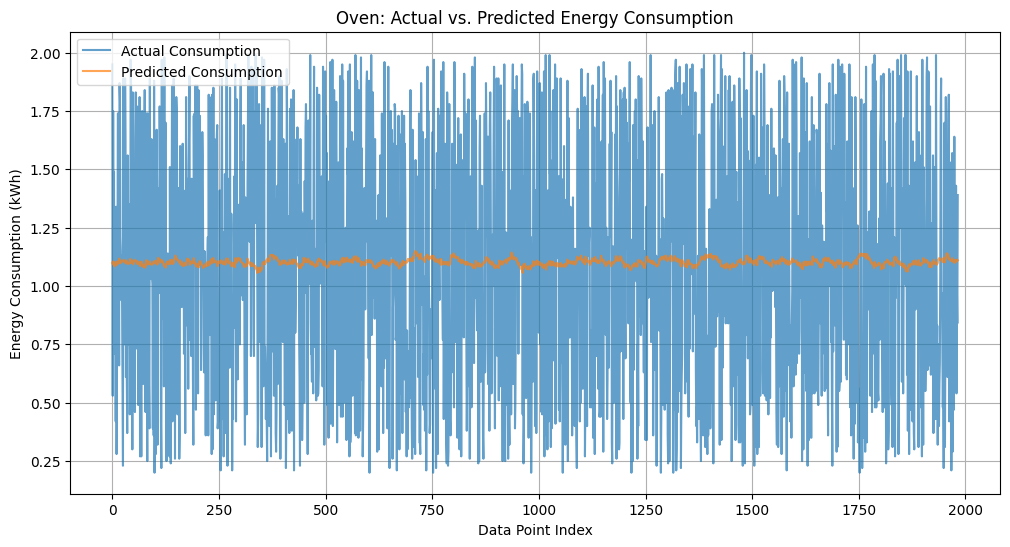

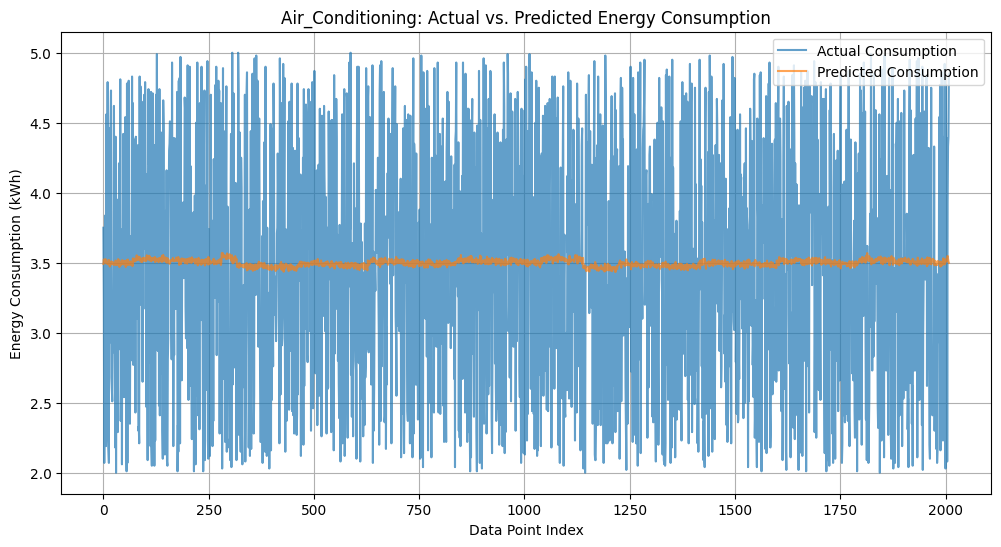

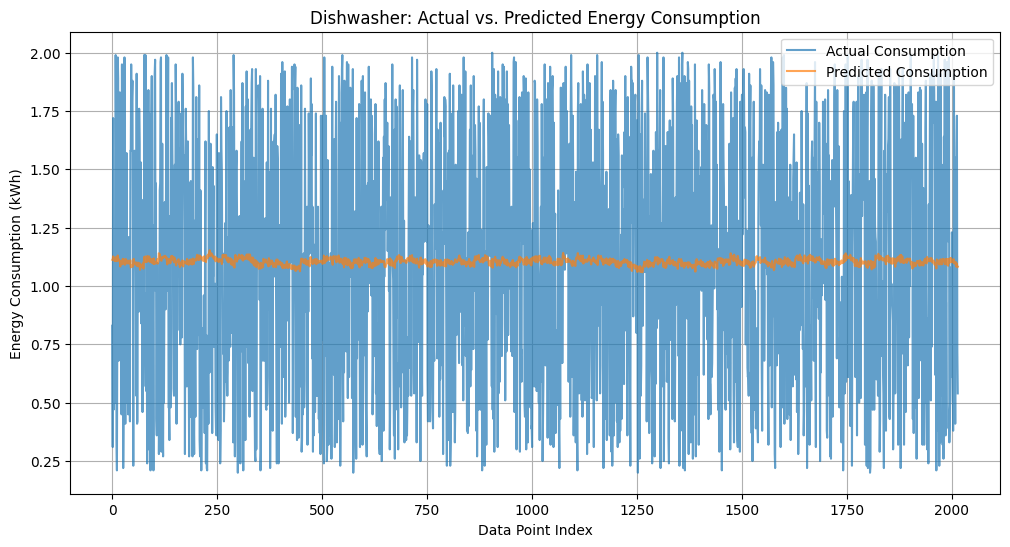

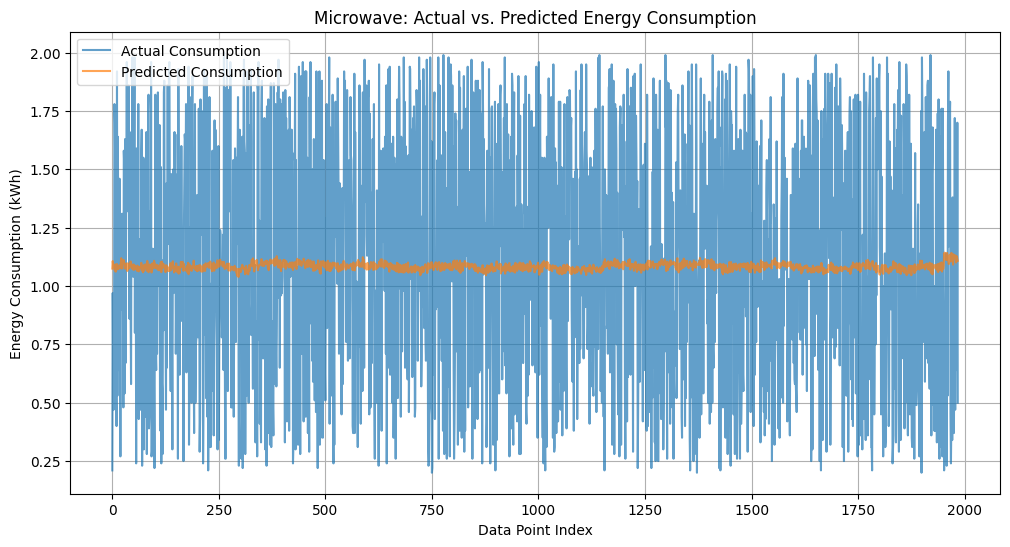

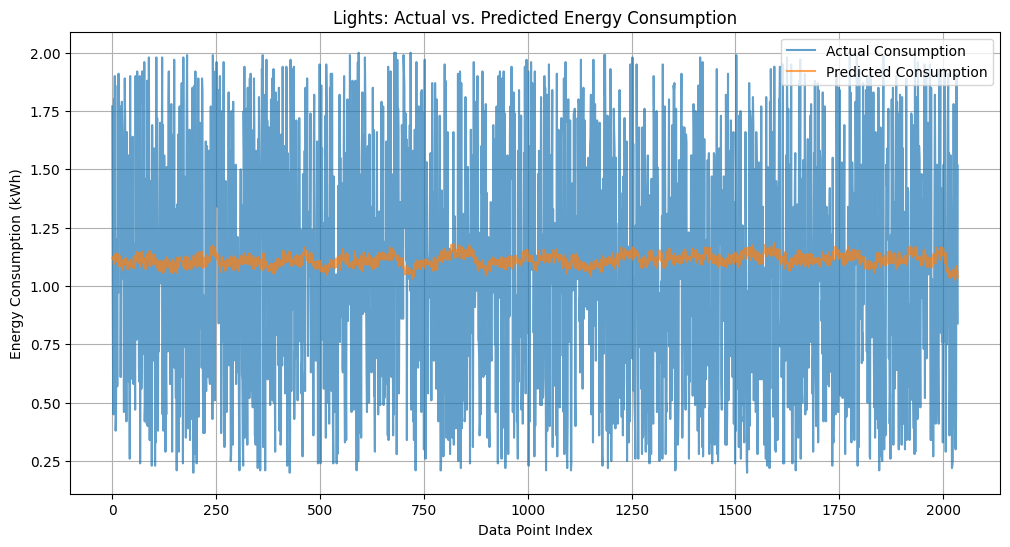

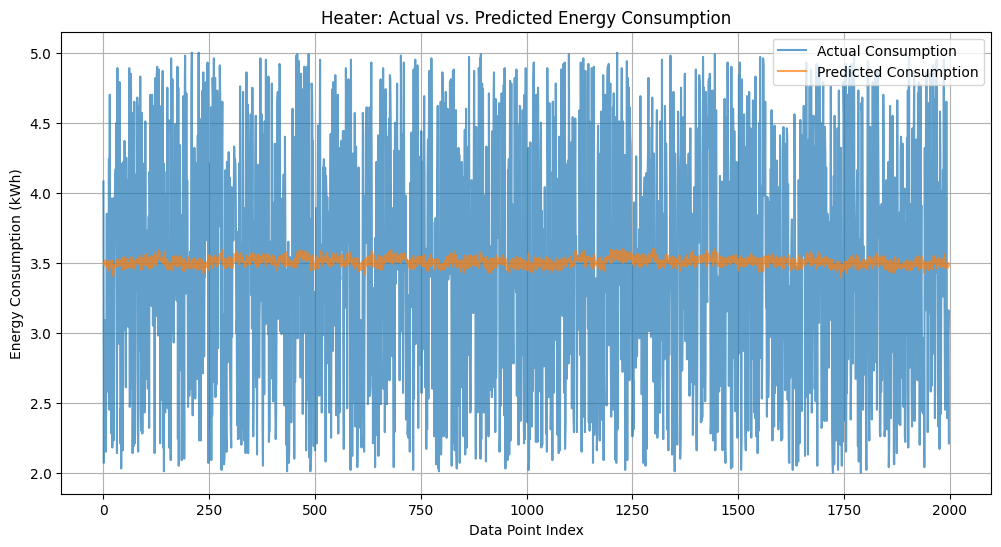

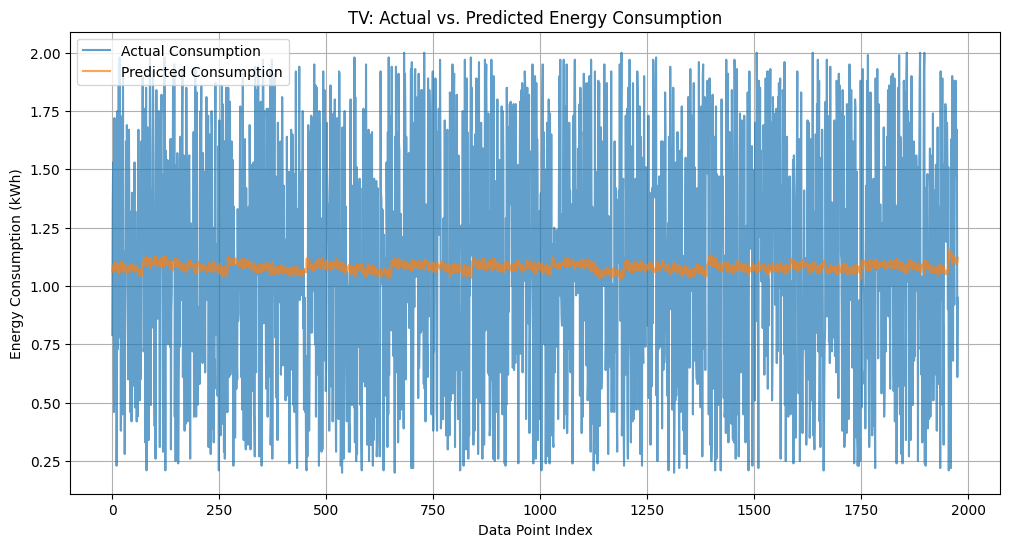

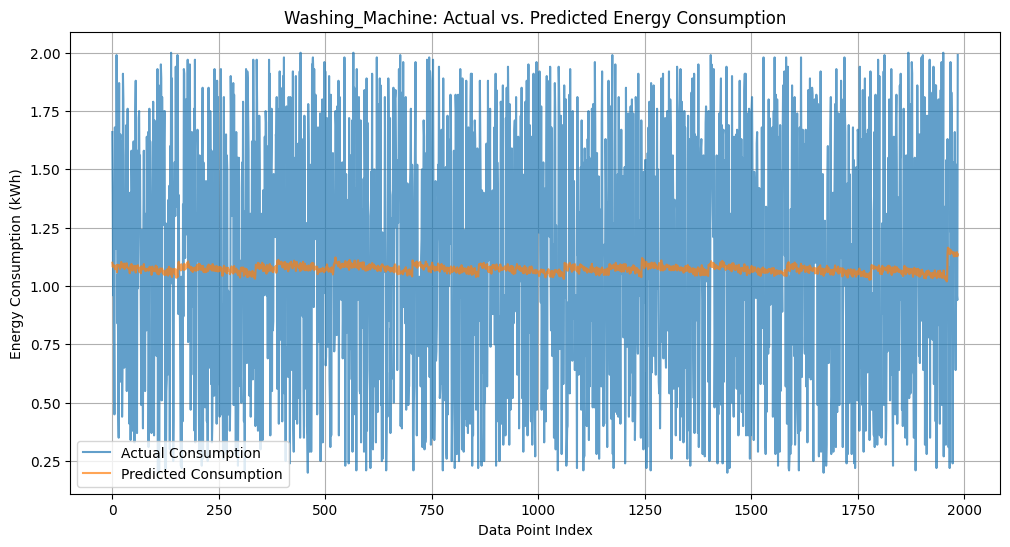

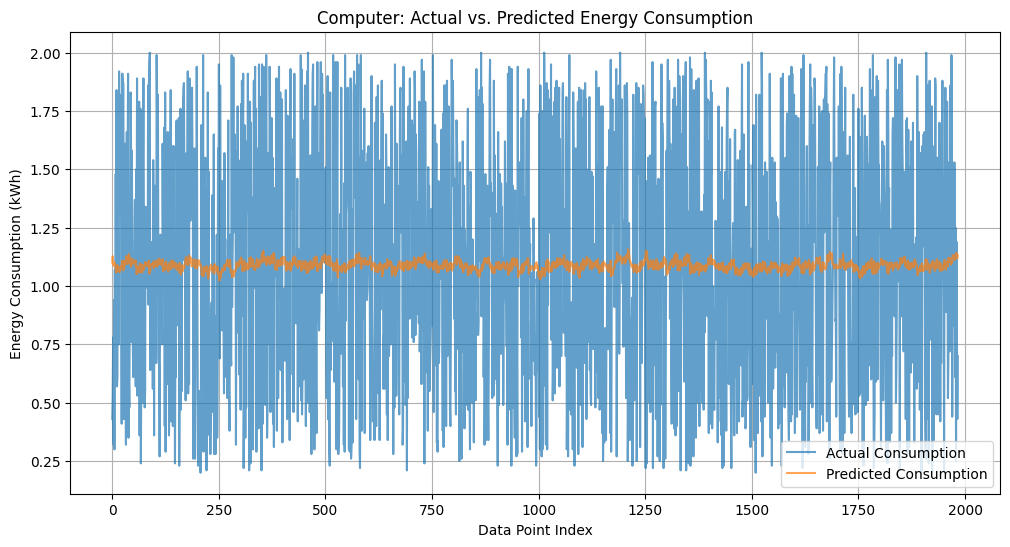

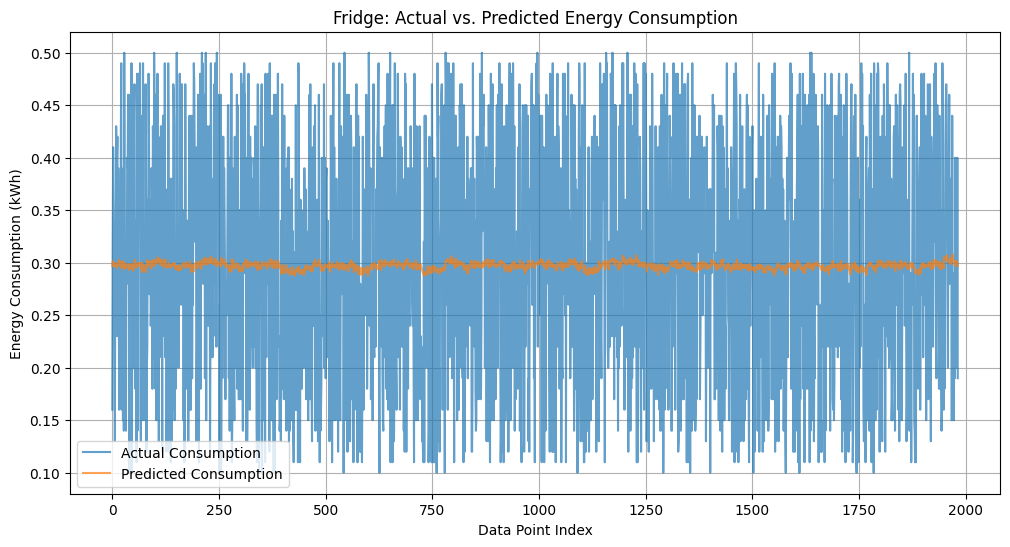

In [3]:
import matplotlib.pyplot as plt

# Iterate through each appliance to create plots
for appliance, results in model_results.items():
    y_test = results['y_test']
    predictions = results['predictions']

    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label='Actual Consumption', alpha=0.7)
    plt.plot(predictions, label='Predicted Consumption', alpha=0.7)
    plt.title(f'{appliance}: Actual vs. Predicted Energy Consumption')
    plt.xlabel('Data Point Index')
    plt.ylabel('Energy Consumption (kWh)')
    plt.legend()
    plt.grid(True)
    plt.show()

## Save Trained Models

### Subtask:
Save each trained Linear Regression model to a separate file (e.g., 'linear_regression_<appliance>.pkl') using the joblib library for persistence.


**Reasoning**:
The subtask requires saving each trained Linear Regression model to a separate file using `joblib`. This step will import the `joblib` library, iterate through the `model_results` dictionary, construct unique filenames for each appliance's model, and then use `joblib.dump()` to save each model.



In [4]:
import joblib

# Iterate through the model_results dictionary to save each model
for appliance, results in model_results.items():
    model = results['model']
    filename = f"linear_regression_{appliance}.pkl"
    joblib.dump(model, filename)
    print(f"Saved {appliance} model to {filename}")

print("All models saved successfully.")

Saved Oven model to linear_regression_Oven.pkl
Saved Air_Conditioning model to linear_regression_Air_Conditioning.pkl
Saved Dishwasher model to linear_regression_Dishwasher.pkl
Saved Microwave model to linear_regression_Microwave.pkl
Saved Lights model to linear_regression_Lights.pkl
Saved Heater model to linear_regression_Heater.pkl
Saved TV model to linear_regression_TV.pkl
Saved Washing_Machine model to linear_regression_Washing_Machine.pkl
Saved Computer model to linear_regression_Computer.pkl
Saved Fridge model to linear_regression_Fridge.pkl
All models saved successfully.


## Generate Performance Comparison Table

### Subtask:
Create a summary DataFrame containing the appliance name, MAE, and RMSE for each trained model, useful for performance comparison and reporting.


**Reasoning**:
To generate the performance comparison table, I will iterate through the `model_results` dictionary, extract the MAE and RMSE for each appliance, and then compile these into a new pandas DataFrame as specified in the instructions.



In [5]:
import pandas as pd

# Initialize an empty list to store performance data
performance_data = []

# Iterate through the model_results dictionary
for appliance, results in model_results.items():
    # Extract MAE and RMSE
    mae = results['mae']
    rmse = results['rmse']

    # Append a dictionary to the list
    performance_data.append({
        'Appliance': appliance,
        'MAE': mae,
        'RMSE': rmse
    })

# Convert the list of dictionaries into a pandas DataFrame
performance_df = pd.DataFrame(performance_data)

# Print the performance_df to display the comparison table
print("Performance Comparison Table:")
print(performance_df)

Performance Comparison Table:
          Appliance       MAE      RMSE
0              Oven  0.448015  0.518181
1  Air_Conditioning  0.743794  0.864376
2        Dishwasher  0.456898  0.524529
3         Microwave  0.450468  0.517850
4            Lights  0.448154  0.517549
5            Heater  0.758643  0.874834
6                TV  0.447587  0.515997
7   Washing_Machine  0.455289  0.523346
8          Computer  0.448458  0.515327
9            Fridge  0.100926  0.116139


## Final Task

### Subtask:
Present the performance comparison table, discuss the observations regarding model performance (e.g., best/worst performing appliances), and provide a summary of the analysis.


## Summary:

### Data Analysis Key Findings

*   **Appliance Discovery and Data Loading**: Ten unique appliances were identified: 'Oven', 'Air\_Conditioning', 'Dishwasher', 'Microwave', 'Lights', 'Heater', 'TV', 'Washing\_Machine', 'Computer', and 'Fridge'. Corresponding training and testing datasets for each appliance were successfully loaded.
*   **Model Training and Evaluation**: Linear Regression models were trained for all ten appliances. Predictions were generated, and evaluation metrics (Mean Absolute Error, MAE, and Root Mean Squared Error, RMSE) were calculated for each.
*   **Performance Comparison**:
    *   The model performed **best for 'Fridge'**, exhibiting the lowest errors with an MAE of 0.1009 and an RMSE of 0.1161.
    *   The model performed **worst for 'Heater'** (MAE: 0.7586, RMSE: 0.8748) and 'Air\_Conditioning' (MAE: 0.7438, RMSE: 0.8644), indicating higher prediction errors for these appliances.
    *   Other appliances like 'Oven', 'Dishwasher', 'Microwave', 'Lights', 'TV', 'Washing\_Machine', and 'Computer' showed comparable MAE values ranging approximately from 0.4476 to 0.4569 and RMSE values from 0.5153 to 0.5245.
*   **Visualization**: Line plots comparing actual versus predicted energy consumption were generated for each appliance, providing a visual assessment of model performance.
*   **Model Persistence**: All trained Linear Regression models were successfully saved as individual `.pkl` files for future use.

### Insights or Next Steps

*   The significant variation in model performance across appliances suggests that a single Linear Regression approach might not be optimal for all. Appliances like 'Fridge' are well-modeled, while 'Heater' and 'Air\_Conditioning' present challenges.
*   For appliances with high error rates such as 'Heater' and 'Air\_Conditioning', explore more advanced regression models (e.g., Random Forest, Gradient Boosting) or conduct further feature engineering to improve prediction accuracy.
